In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from statistics import mean
import joblib
from sklearn.metrics import accuracy_score

In [2]:
# Remove unnecessary columns
def clean_csv(old_filename, new_filename, remove_col_list):
    try:
        df = pd.read_csv(old_filename)
        df.drop(columns=remove_col_list, inplace=True)
        df.to_csv(new_filename, index=False)

        print(f'file: "{old_filename}" cleaned successfully')
        return True
    except Exception as e:
        print(f'file: "{old_filename}" clean failed ({e})')
        return False

In [3]:
# Loads features and target variables
def load_data(filename, y_target_name, num_rows=-1, pos=0):
    df = pd.read_csv(filename)
    if num_rows > 0:
        df = df[pos : pos + num_rows]
    elif pos != 0:
        df = df[pos:]

    X = df.drop(columns=[y_target_name])
    y = df[y_target_name]

    return X, y, df

In [4]:
def show_corr_matrix(df, output_filename):
    non_valid_cols = [
        df.columns[i]
        for i, item in enumerate(df.dtypes)
        if not pd.api.types.is_numeric_dtype(item)
    ]
    df.drop(columns=non_valid_cols, inplace=True)
    matrix = df.corr()
    plt.figure(figsize=(32, 16))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("UCI Phishing URL Correlation Heatmap")
    plt.savefig(output_filename)

In [5]:
def get_training_test_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
    return X_train, X_test, y_train, y_test

In [6]:
def logistic_regression_model_training(X_train, X_test, y_train, y_test):
    C_grid = np.logspace(-4, 4, 20)
    y_train_log_loss_data = []
    y_test_log_loss_data = []
    for i, C in enumerate(C_grid):
        print(f"working on {i}")
        clf = LogisticRegression(C=C, l1_ratio=0, solver="lbfgs", max_iter=500).fit(
            X_train, y_train
        )
        y_train_pred = clf.predict_proba(X_train)
        y_test_pred = clf.predict_proba(X_test)
        y_train_log_loss = log_loss(y_train, y_train_pred)
        y_test_log_loss = log_loss(y_test, y_test_pred)

        # print(f"{y_train_pred=}")
        # print(f"{y_test_pred=}")
        print(f"{y_train_log_loss=}")
        print(f"{y_test_log_loss=}")
        y_train_log_loss_data.append(y_train_log_loss)
        y_test_log_loss_data.append(y_test_log_loss)

    plt.figure()
    plt.plot(
        C_grid,
        y_train_log_loss_data,
        "o-",
        color="blue",
        label="Training Data Log-Loss",
        markersize=3,
    )
    plt.plot(
        C_grid,
        y_test_log_loss_data,
        "o-",
        color="red",
        label="Test Data Log-Loss",
        markersize=3,
    )

    plt.xlabel("C")
    plt.ylabel("Log-Loss")
    plt.title("Log-Loss of Training and Test Data Vs C")
    # plt.ylim([0, 1])
    plt.xscale("log")
    plt.legend()
    plt.savefig("./outputs/logistic_regression_log_loss_c.png")
    return clf

In [7]:
clean_csv(
    "./data/uci_phishing_url_dataset.csv",
    "./data/uci_phishing_url_dataset_clean.csv",
    [
        "FILENAME",
        "URL",
        "Domain",
        "TLD",
        "Title",
        "HasTitle",
        "DomainTitleMatchScore",
        "URLTitleMatchScore",
        "HasFavicon",
        "Robots",
        "IsResponsive",
        "NoOfURLRedirect",
        "NoOfSelfRedirect",
        "HasDescription",
        "NoOfPopup",
        "NoOfiFrame",
        "HasExternalFormSubmit",
        "HasSocialNet",
        "HasSubmitButton",
        "HasHiddenFields",
        "HasPasswordField",
        "Bank",
        "Pay",
        "Crypto",
        "HasCopyrightInfo",
        "NoOfImage",
        "NoOfCSS",
        "NoOfJS",
        "NoOfSelfRef",
        "NoOfEmptyRef",
        "NoOfExternalRef",
        "URLSimilarityIndex",
        "CharContinuationRate",
        "TLDLegitimateProb",
        "URLCharProb",
    ],
)

file: "./data/uci_phishing_url_dataset.csv" cleaned successfully


True

remove "FILENAME" column from data


In [ ]:
X, y, df = load_data("./data/uci_phishing_url_dataset_clean.csv", "IsLegit", 100000)

X[X["NoOfObfuscatedChar"] > 0]

,URLLength,DomainLength,IsDomainIP,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength
77,92,16,0,3,1,1,9,0.098,35,0.380,39,0.424,0,0,3,7,0.109,1,3,204
903,126,74,0,4,2,1,3,0.024,98,0.778,11,0.087,0,1,1,7,0.071,1,127,1198
1093,188,14,0,3,1,1,3,0.016,118,0.628,31,0.165,4,1,3,11,0.101,1,2,1579
3771,57,19,0,3,1,1,3,0.053,39,0.684,2,0.035,0,0,1,7,0.140,1,219,439
4215,65,21,0,2,1,1,3,0.046,50,0.769,2,0.031,0,0,1,5,0.092,0,9,117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97256,49,29,0,3,1,1,3,0.061,33,0.673,3,0.061,0,0,1,4,0.102,1,88,9703
97422,62,33,0,3,3,1,3,0.048,44,0.710,2,0.032,0,0,1,7,0.129,1,1504,85411
98363,170,18,0,3,1,1,3,0.018,123,0.724,14,0.082,2,1,2,9,0.082,1,51,206
98377,215,52,0,3,3,1,12,0.056,135,0.628,43,0.200,1,1,12,12,0.121,0,474,780


In [9]:
show_corr_matrix(df, "./outputs/uci_phishing_url_corr_matrix.png")

Error in callback <function flush_figures at 0x72b62ec21ab0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

working on 0
y_train_log_loss=0.0387382059368718
y_test_log_loss=0.03945010803317057
working on 1


/home/kelly/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.032897378761690604
y_test_log_loss=0.03318714774705578
working on 2


/home/kelly/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.02639554701785941
y_test_log_loss=0.026366290204085638
working on 3


...

y_train_log_loss=0.0032931206441987205
y_test_log_loss=0.003282799327280841
working on 17


/home/kelly/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.003274914811656123
y_test_log_loss=0.003264725618957247
working on 18
y_train_log_loss=0.0033340879393176197
y_test_log_loss=0.0033253340262058757
working on 19


/home/kelly/.pyenv/versions/3.12.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.003371280847879444
y_test_log_loss=0.0033626580695264073


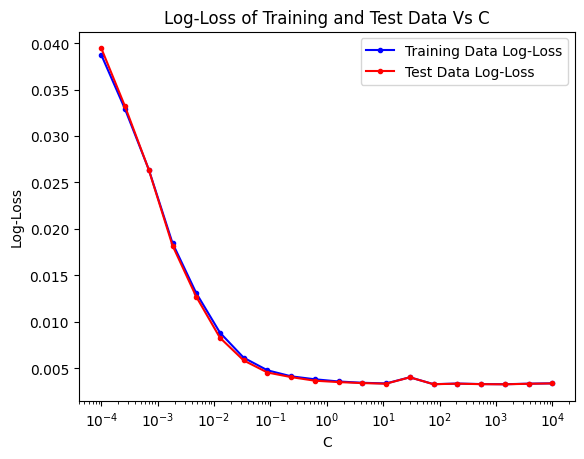

In [ ]:
X_train, X_test, y_train, y_test = get_training_test_data(X, y)
clf = logistic_regression_model_training(X_train, X_test, y_train, y_test)

In [ ]:
joblib.dump(clf, "./models/logit_model.pkl")

['./models/logit_model.pkl']

In [ ]:
clf2 = joblib.load("./models/logit_model.pkl")
X_new, y_new, df_new = load_data(
    "./data/uci_phishing_url_dataset_clean.csv", "IsLegit", pos=100000
)
print(clf2.coef_)
y_new_pred = clf2.predict(X_new)

accuracy = accuracy_score(y_new, y_new_pred)
print(f"Accuracy: {accuracy}")

[[-1.45011078e+01  3.00814379e+01 -4.05174196e-02 -5.59447798e-01
  -1.57514194e+00 -3.87937991e-02 -1.54484265e-01 -2.08187255e-03
  -1.56688745e+01 -3.61734976e-01 -1.66745248e+01 -2.05490864e-01
  -3.94971670e-01 -3.23224743e-01 -6.63658299e-02 -1.56375775e+01
  -5.59723401e-01  3.03110292e+01  3.30999075e-02 -8.36018803e-04]]
Accuracy: 0.9988803833838715
